# Strict Lifestyle

In [9]:
import pandas as pd
import plotly.express as px

df1 = pd.read_csv("student_lifestyle_dataset.csv")
df2 = pd.read_csv("Gaming_Academic_Performance.csv")
df3_mat = pd.read_csv("student-mat.csv", sep=";")
df3_por = pd.read_csv("student-por.csv", sep=";")
df4 = pd.read_csv("student_habits_performance.csv")

In [10]:
df1.head()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High


In [11]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ---------- Combine Dataset 3 ----------
df3_mat["Subject"] = "Math"
df3_por["Subject"] = "Portuguese"
df3 = pd.concat([df3_mat, df3_por], ignore_index=True)

# ---------- Grade group by percentile ----------
def add_grade_group(df, grade_col):
    df = df.copy()
    df["Grade Group"] = pd.qcut(
        df[grade_col],
        q=3,
        labels=["Low", "Medium", "High"],
        duplicates="drop"
    )
    return df

df1 = add_grade_group(df1, "GPA")
df2 = add_grade_group(df2, "grades")
df3 = add_grade_group(df3, "G3")
df4 = add_grade_group(df4, "exam_grade")   # đổi thành exam_score nếu cột của m là exam_score

grade_order = ["Low", "Medium", "High"]

# ---------- Summaries ----------
s1 = (
    df1.groupby("Grade Group", observed=False)["Study_Hours_Per_Day"]
    .mean()
    .reindex(grade_order)
)

s2 = (
    df2.groupby("Grade Group", observed=False)["study_hours"]
    .mean()
    .reindex(grade_order)
)

s3 = (
    df3.groupby(["Grade Group", "Subject"], observed=False)["studytime"]
    .mean()
    .reset_index()
)

s4 = (
    df4.groupby("Grade Group", observed=False)["study_hours_per_day"]
    .mean()
    .reindex(grade_order)
)

# ---------- Figure 1: Study time across datasets ----------
fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[
        "Dataset 1: Student Lifestyle",
        "Dataset 2: Gaming & Academic Performance",
        "Dataset 3: Student Alcohol Consumption",
        "Dataset 4: Student Habits"
    ],
    vertical_spacing=0.18,
    horizontal_spacing=0.12
)

# Dataset 1
fig.add_trace(
    go.Bar(
        x=grade_order,
        y=s1.values,
        name="Dataset 1",
        showlegend=False
    ),
    row=1,
    col=1
)

# Dataset 2
fig.add_trace(
    go.Bar(
        x=grade_order,
        y=s2.values,
        name="Dataset 2",
        showlegend=False
    ),
    row=1,
    col=2
)

# Dataset 3: Math + Portuguese as grouped bars
for subject in ["Math", "Portuguese"]:
    temp = (
        s3[s3["Subject"] == subject]
        .set_index("Grade Group")
        .reindex(grade_order)
    )
    fig.add_trace(
        go.Bar(
            x=grade_order,
            y=temp["studytime"],
            name=subject
        ),
        row=2,
        col=1
    )

# Dataset 4
fig.add_trace(
    go.Bar(
        x=grade_order,
        y=s4.values,
        name="Dataset 4",
        showlegend=False
    ),
    row=2,
    col=2
)

fig.update_layout(
    title_text="Study Time and Academic Performance Across Four Datasets",
    barmode="group",
    height=750,
    width=1000,
    template="plotly_white",
    legend_title_text="Subject",
)

fig.update_xaxes(title_text="Grade Group")
fig.update_yaxes(title_text="Average Study Time / Hours")

fig.show()

KeyError: 'G3'

In [12]:
print("df1:", df1.columns.tolist())
print("df2:", df2.columns.tolist())
print("df3_mat:", df3_mat.columns.tolist())
print("df4:", df4.columns.tolist())

df1: ['Student_ID', 'Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 'GPA', 'Stress_Level', 'Grade Group']
df2: ['student_id', 'age', 'gender', 'gaming_hours', 'study_hours', 'sleep_hours', 'attendance', 'gaming_genre', 'social_activity', 'device_usage', 'reaction_time_ms', 'addiction_score', 'stress_level', 'grades', 'Grade Group']
df3_mat: ['school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3', 'Subject']
df4: ['student_id', 'age', 'gender', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation', 'exam_score']


In [13]:
df3_mat["Subject"] = "Math"
df3_por["Subject"] = "Portuguese"
df3 = pd.concat([df3_mat, df3_por], ignore_index=True)

In [14]:
df3.head()

,"school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3",Subject
0,"GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mot...",Math
1,"GP,F,17,U,GT3,T,1,1,at_home,other,course,fathe...",Math
2,"GP,F,15,U,LE3,T,1,1,at_home,other,other,mother...",Math
3,"GP,F,15,U,GT3,T,4,2,health,services,home,mothe...",Math
4,"GP,F,16,U,GT3,T,3,3,other,other,home,father,1,...",Math


In [15]:
def add_grade_group(df, grade_col):
    df = df.copy()
    df["Grade Group"] = pd.qcut(
        df[grade_col].rank(method="first"),
        q=3,
        labels=["Low", "Medium", "High"]
    )
    return df

df1 = add_grade_group(df1, "GPA")
df2 = add_grade_group(df2, "grades")
df3 = add_grade_group(df3, "G3")
df4 = add_grade_group(df4, "exam_score")

KeyError: 'G3'

In [16]:
print(df3.columns.tolist())
print(df3.head())

['school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3', 'Subject']
  school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3  \
0  GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mot...                                                                                                                                                                                    
1  GP,F,17,U,GT3,T,1,1,at_home,other,course,fathe...                                                                                                                                                                                    
2  GP,F,15,U,LE3,T,1,1,at_home,other,other,mother...      

In [17]:
df3 = add_grade_group(df3, "G3")

KeyError: 'G3'

In [18]:
df3.columns = df3.columns.str.strip()
df3 = add_grade_group(df3, "G3")

KeyError: 'G3'

In [21]:
df3_mat = pd.read_csv("student-mat.csv", sep=";")
df3_por = pd.read_csv("student-por.csv", sep=";")

df3_mat["Subject"] = "Math"
df3_por["Subject"] = "Portuguese"

df3 = pd.concat([df3_mat, df3_por], ignore_index=True)
df3.columns = df3.columns.str.strip()

print(df3.columns.tolist())

df3 = add_grade_group(df3, "G3")

['school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3', 'Subject']


KeyError: 'G3'

In [22]:
print([repr(c) for c in df3.columns if "G3" in c])

["'school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3'"]


In [24]:
df3.columns = (
    df3.columns
    .str.replace("\ufeff", "", regex=False)
    .str.strip()
)

print([repr(c) for c in df3.columns if "G3" in c])

df3 = add_grade_group(df3, "G3")

["'school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3'"]


KeyError: "'G3'"

In [27]:
df3_mat = pd.read_csv("student-mat.csv", sep=None, engine="python")
df3_por = pd.read_csv("student-por.csv", sep=None, engine="python")

In [28]:
# Add subject column
df3_mat["Subject"] = "Math"
df3_por["Subject"] = "Portuguese"

# Merge / append Math + Portuguese into one table
df3 = pd.concat([df3_mat, df3_por], ignore_index=True)

# Check columns
print(df3.columns.tolist())
print(df3.head())

['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'Subject']
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  freetime goout  Dalc  Walc  health absences  G1  G2  G3 Subject  
0        3     4     1     1       3        6   5   6   6    Math  
1        3     3     1     1       3  

In [29]:
# Create Grade Group by balanced percentile
df3 = add_grade_group(df3, "G3")

# Check result
df3[["Subject", "studytime", "paid", "absences", "G3", "Grade Group"]].head()

,Subject,studytime,paid,absences,G3,Grade Group
0,Math,2,no,6,6,Low
1,Math,2,no,4,6,Low
2,Math,2,yes,10,10,Low
3,Math,3,yes,2,15,High
4,Math,2,yes,4,10,Low


In [30]:
def add_grade_group(df, grade_col):
    df = df.copy()
    df["Grade Group"] = pd.qcut(
        df[grade_col].rank(method="first"),
        q=3,
        labels=["Low", "Medium", "High"]
    )
    return df

df1 = add_grade_group(df1, "GPA")
df2 = add_grade_group(df2, "grades")
df3 = add_grade_group(df3, "G3")
df4 = add_grade_group(df4, "exam_score")

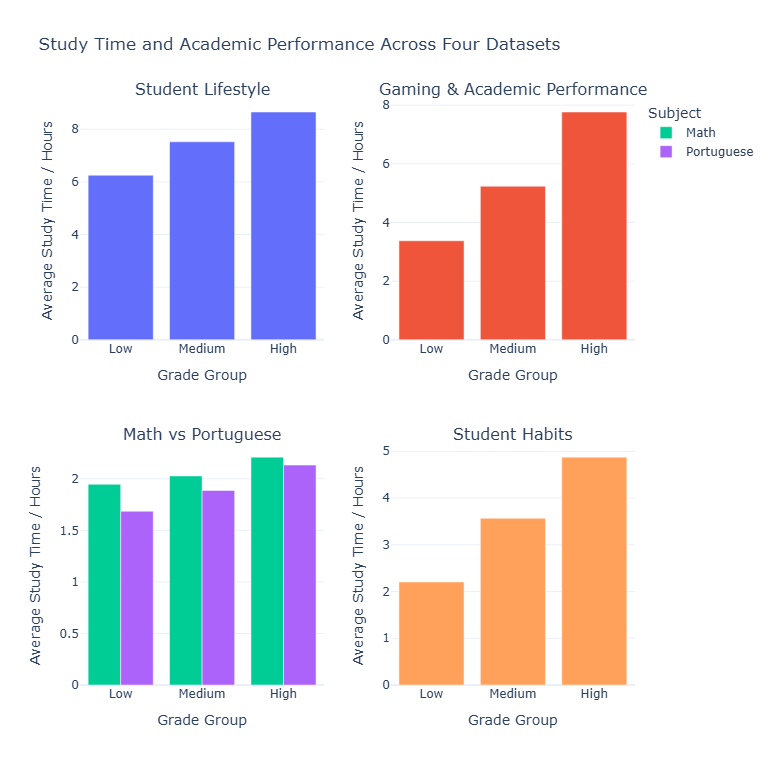

In [31]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

grade_order = ["Low", "Medium", "High"]

s1 = df1.groupby("Grade Group", observed=False)["Study_Hours_Per_Day"].mean().reindex(grade_order)
s2 = df2.groupby("Grade Group", observed=False)["study_hours"].mean().reindex(grade_order)

s3 = (
    df3.groupby(["Grade Group", "Subject"], observed=False)["studytime"]
    .mean()
    .reset_index()
)

s4 = df4.groupby("Grade Group", observed=False)["study_hours_per_day"].mean().reindex(grade_order)

fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[
        "Student Lifestyle",
        "Gaming & Academic Performance",
        "Math vs Portuguese",
        "Student Habits"
    ],
    vertical_spacing=0.18,
    horizontal_spacing=0.12
)

fig.add_trace(go.Bar(x=grade_order, y=s1.values, showlegend=False), row=1, col=1)
fig.add_trace(go.Bar(x=grade_order, y=s2.values, showlegend=False), row=1, col=2)

for subject in ["Math", "Portuguese"]:
    temp = s3[s3["Subject"] == subject].set_index("Grade Group").reindex(grade_order)
    fig.add_trace(
        go.Bar(x=grade_order, y=temp["studytime"], name=subject),
        row=2,
        col=1
    )

fig.add_trace(go.Bar(x=grade_order, y=s4.values, showlegend=False), row=2, col=2)

fig.update_layout(
    title_text="Study Time and Academic Performance Across Four Datasets",
    barmode="group",
    height=750,
    width=1000,
    template="plotly_white",
    legend_title_text="Subject"
)

fig.update_xaxes(title_text="Grade Group")
fig.update_yaxes(title_text="Average Study Time / Hours")

fig.show()